# 04. Đánh giá & So sánh mô hình

Notebook này thực hiện các phân tích đánh giá chi tiết cho các mô hình:
- Tải tệp lưu trữ các giá trị dự báo sinh ra từ bước trước.
- Tính toán các chỉ số sai số MAE, RMSE, MAPE cho từng mô hình trên tập kiểm thử.
- Tổng hợp bảng so sánh hiệu năng và lưu vào tệp `results/metrics.csv`.
- Trực quan hóa các đường dự báo so với giá trị thực tế và lưu đồ thị vào thư mục `figures/`.

In [1]:
import sys
sys.path.append('../')

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.evaluation import calculate_metrics

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

## 1. Tải kết quả dự đoán

In [2]:
predictions_path = "../results/predictions.csv"
pred_df = pd.read_csv(predictions_path)
pred_df["date"] = pd.to_datetime(pred_df["date"])
pred_df.head()

,date,y_true,naive,moving_average,linear_regression_baseline,linear_regression_fourier,xgboost,lstm,gru,transformer
0,2018-03-12 00:00:00,-0.551855,-0.551902,-0.562565,-0.558667,-0.566875,-0.558112,-0.543821,-0.777511,-0.599068
1,2018-03-12 00:15:00,-0.571000,-0.551902,-0.557271,-0.562361,-0.570076,-0.558112,-0.548651,-0.773723,-0.592946
2,2018-03-12 00:30:00,-0.571000,-0.571048,-0.551976,-0.577832,-0.585013,-0.569854,-0.558969,-0.769307,-0.637029
3,2018-03-12 00:45:00,-0.590146,-0.571048,-0.546682,-0.581423,-0.588059,-0.569854,-0.575377,-0.770759,-0.659355
4,2018-03-12 01:00:00,-0.590146,-0.590194,-0.541599,-0.596961,-0.602989,-0.595318,-0.590997,-0.777371,-0.677272


## 2. Tính toán các chỉ số đánh giá sai số (MAE, RMSE, MAPE)

In [3]:
y_true = pred_df["y_true"].values
models = [col for col in pred_df.columns if col not in ["date", "y_true"]]

metrics_results = []
for model in models:
    y_pred = pred_df[model].values
    res = calculate_metrics(y_true, y_pred)
    res["model"] = model
    metrics_results.append(res)

# Thêm SARIMAX vào bảng đánh giá nếu có
sarimax_path = "../results/predictions_sarimax.csv"
if os.path.exists(sarimax_path):
    sarimax_df = pd.read_csv(sarimax_path)
    res_sarx = calculate_metrics(sarimax_df["y_true"].values, sarimax_df["y_pred"].values)
    res_sarx["model"] = "sarimax"
    metrics_results.append(res_sarx)

metrics_df = pd.DataFrame(metrics_results)[["model", "mae", "rmse", "mape"]]
print("Bảng so sánh hiệu năng các mô hình trên tập kiểm thử (Test Set):")
print(metrics_df)


Bảng so sánh hiệu năng các mô hình trên tập kiểm thử (Test Set):
                        model       mae      rmse      mape
0                       naive  0.021976  0.032647  0.226077
1              moving_average  0.335756  0.427069  2.393539
2  linear_regression_baseline  0.015006  0.021197  0.171680
3   linear_regression_fourier  0.015072  0.020854  0.180083
4                     xgboost  0.017837  0.026560  0.197187
5                        lstm  0.236701  0.341856  2.384745
6                         gru  0.152244  0.204022  1.391238
7                 transformer  0.192344  0.260970  1.786163
8                     sarimax  0.500520  0.625529  3.183952


## 3. Lưu bảng so sánh chỉ số đánh giá

In [4]:
metrics_df.to_csv("../results/metrics.csv", index=False)
print("Lưu bảng kết quả so sánh vào results/metrics.csv thành công!")

Lưu bảng kết quả so sánh vào results/metrics.csv thành công!


## 4. Vẽ đồ thị so sánh thực tế vs dự báo

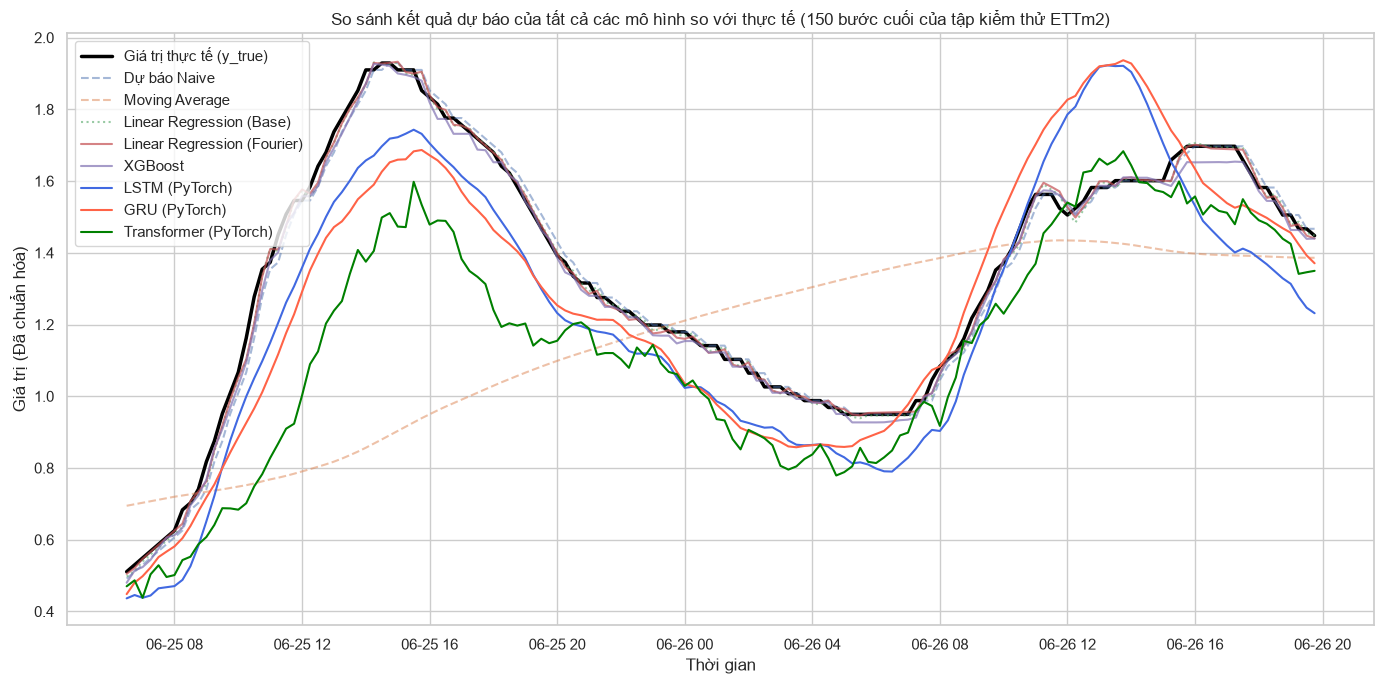

Đã vẽ và lưu figures/y_true_vs_y_pred.png


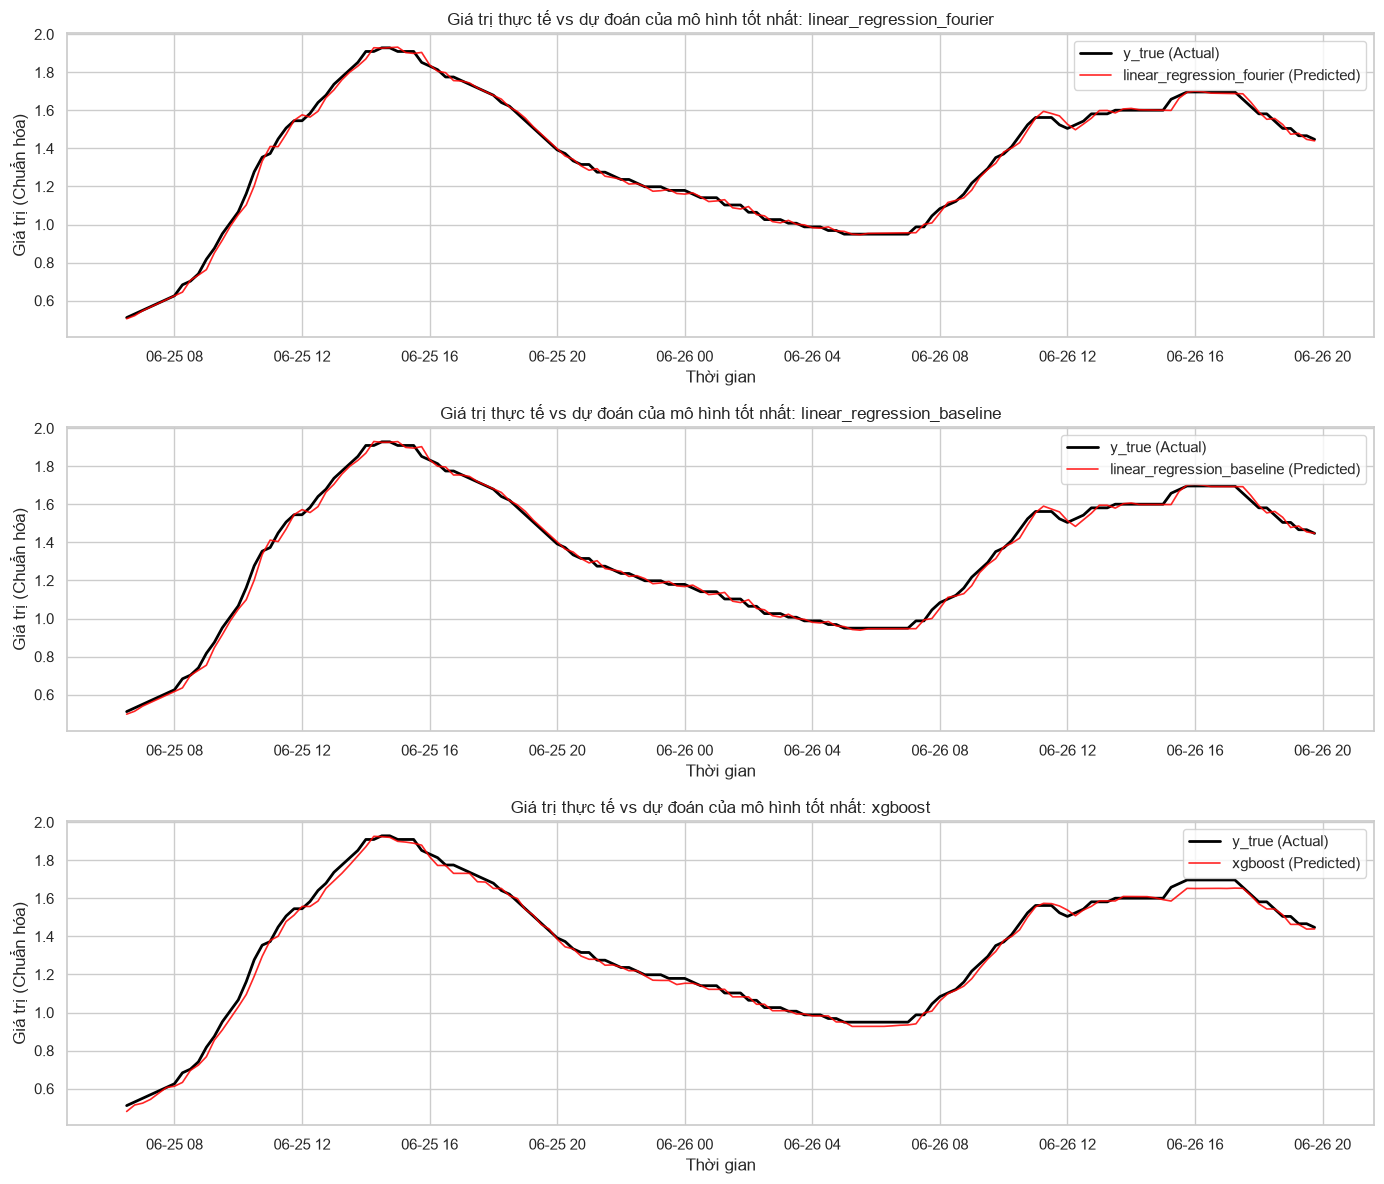

Đã vẽ và lưu figures/predictions_best_models.png


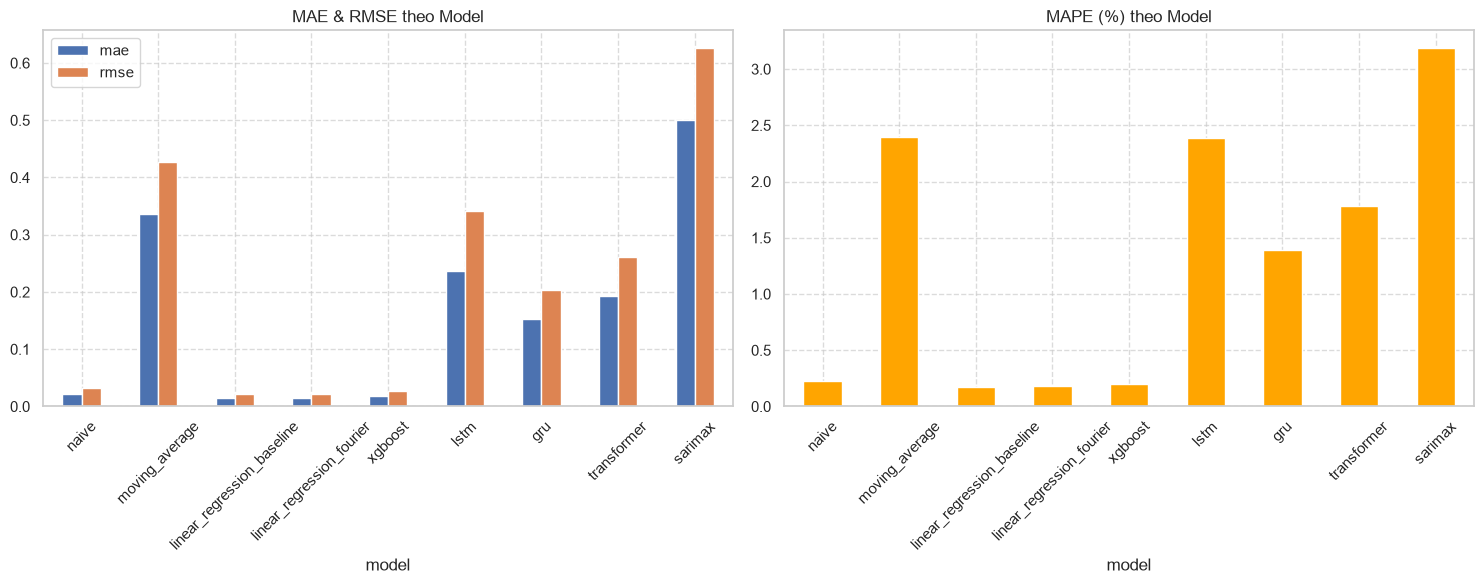

Đã vẽ và lưu figures/metrics_all_models.png


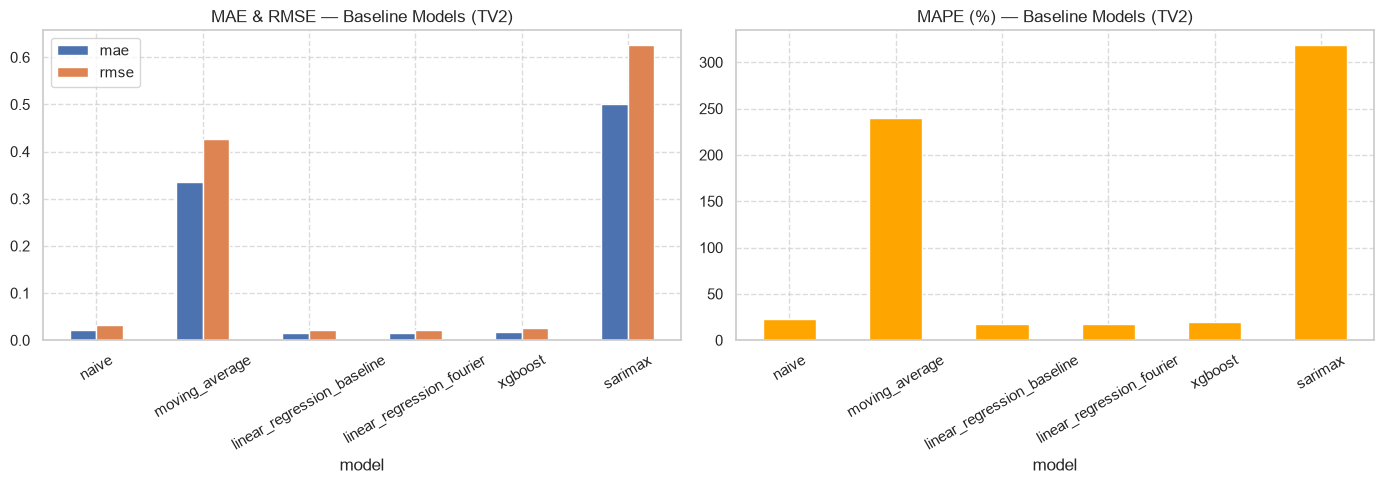

Đã vẽ và lưu figures/baseline_metrics_comparison.png


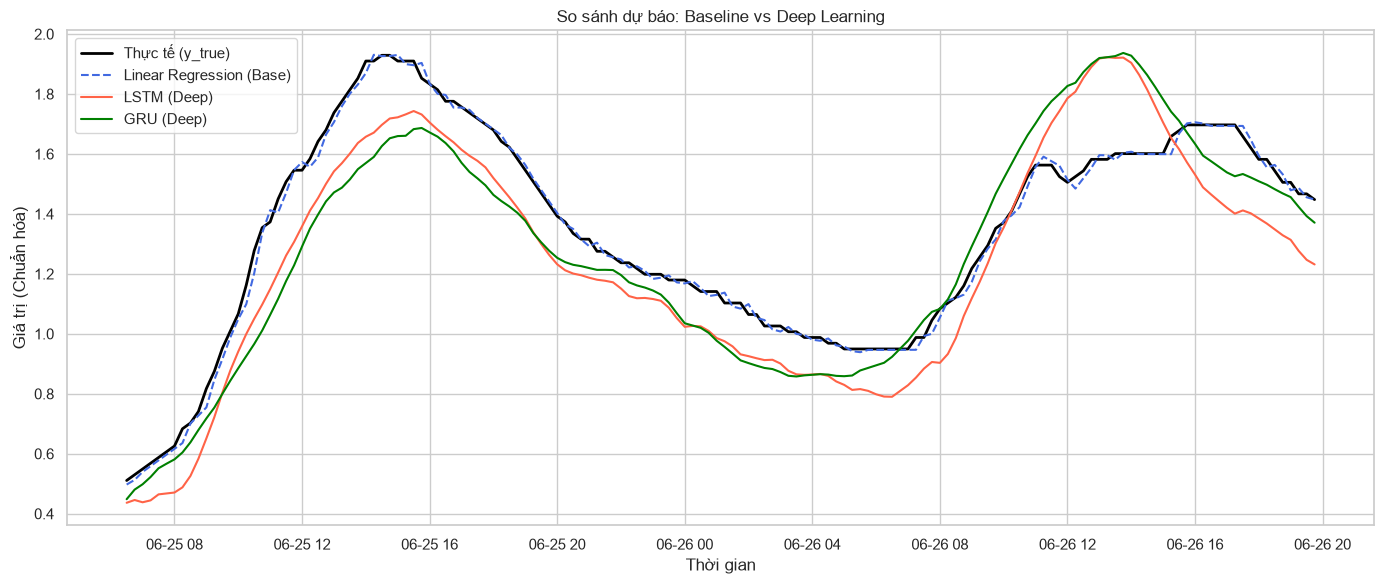

Đã vẽ và lưu figures/predictions_comparison_overlay.png


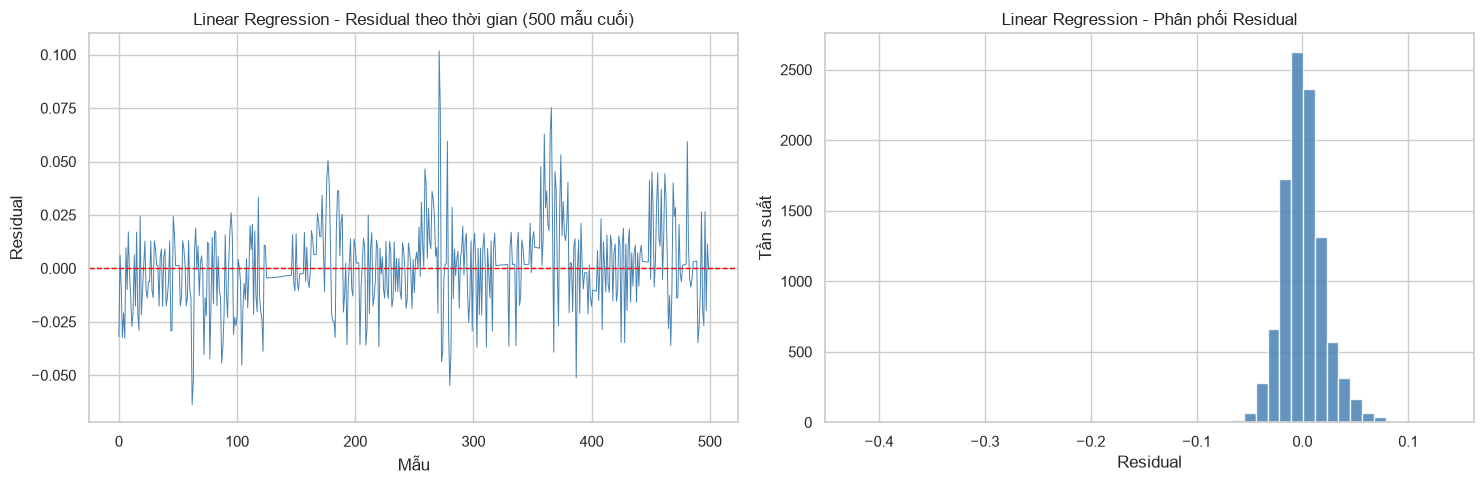

Đã vẽ và lưu figures/residual_linear.png


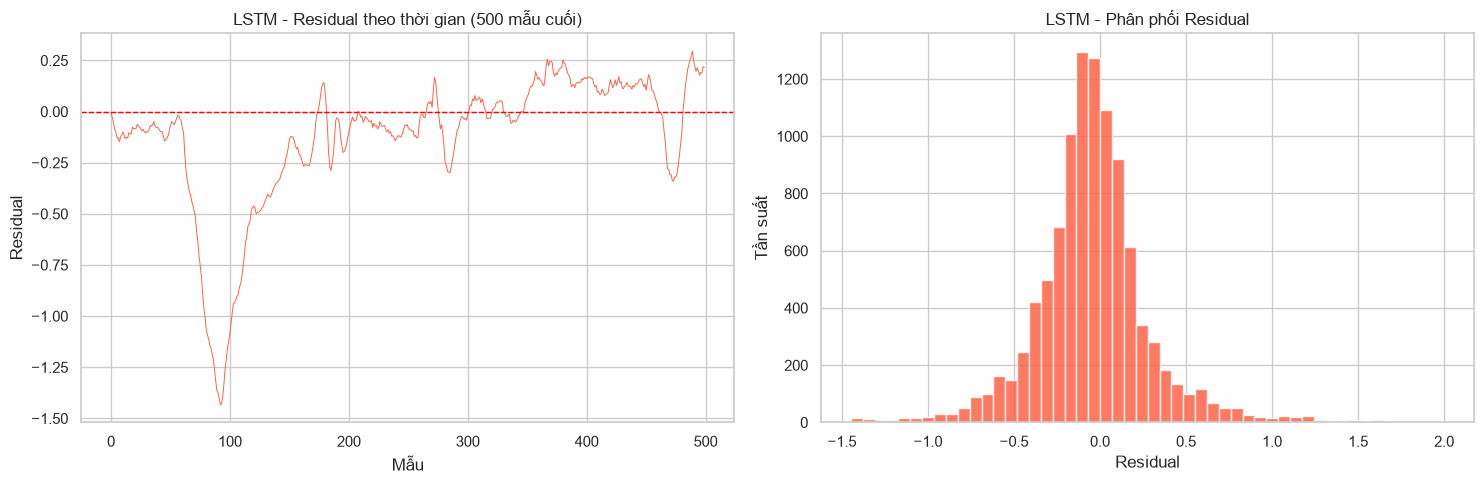

Đã vẽ và lưu figures/residual_lstm.png


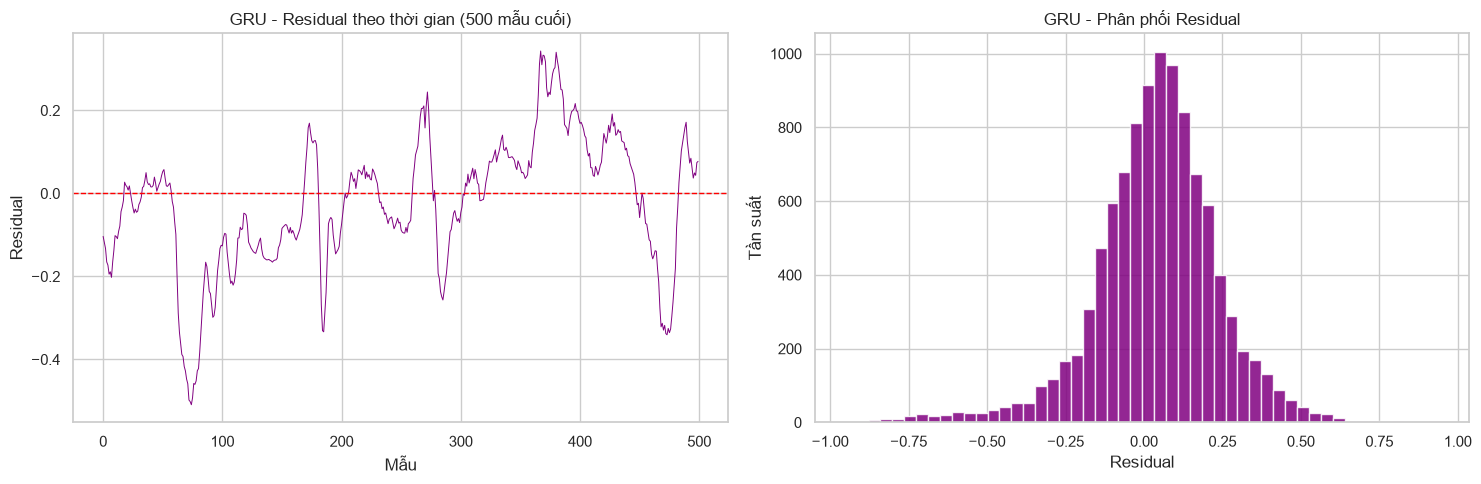

Đã vẽ và lưu figures/residual_best_model.png


In [5]:
plot_subset = pred_df.tail(150).reset_index(drop=True)

# 1. Vẽ đồ thị so sánh thực tế vs dự báo của tất cả các mô hình
plt.figure(figsize=(14, 7))
plt.plot(plot_subset["date"], plot_subset["y_true"], label="Giá trị thực tế (y_true)", color="black", linewidth=2.5)
plt.plot(plot_subset["date"], plot_subset["naive"], label="Dự báo Naive", linestyle="--", alpha=0.5)
plt.plot(plot_subset["date"], plot_subset["moving_average"], label="Moving Average", linestyle="--", alpha=0.5)
plt.plot(plot_subset["date"], plot_subset["linear_regression_baseline"], label="Linear Regression (Base)", linestyle=":", alpha=0.6)
plt.plot(plot_subset["date"], plot_subset["linear_regression_fourier"], label="Linear Regression (Fourier)", alpha=0.7)
plt.plot(plot_subset["date"], plot_subset["xgboost"], label="XGBoost", alpha=0.7)
plt.plot(plot_subset["date"], plot_subset["lstm"], label="LSTM (PyTorch)", color="royalblue", linewidth=1.5)
plt.plot(plot_subset["date"], plot_subset["gru"], label="GRU (PyTorch)", color="tomato", linewidth=1.5)
plt.plot(plot_subset["date"], plot_subset["transformer"], label="Transformer (PyTorch)", color="green", linewidth=1.5)

plt.title("So sánh kết quả dự báo của tất cả các mô hình so với thực tế (150 bước cuối của tập kiểm thử ETTm2)")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị (Đã chuẩn hóa)")
plt.legend(loc="upper left")
plt.grid(True)
plt.tight_layout()
os.makedirs("../figures", exist_ok=True)
plt.savefig("../figures/y_true_vs_y_pred.png", dpi=300)
plt.show()
print("Đã vẽ và lưu figures/y_true_vs_y_pred.png")

# 2. Vẽ so sánh top 3 mô hình tốt nhất (dựa trên RMSE trong metrics_df)
best_models = metrics_df.sort_values("rmse")["model"].tolist()[:3]
fig, axes = plt.subplots(len(best_models), 1, figsize=(14, 4 * len(best_models)), sharey=True)
if len(best_models) == 1:
    axes = [axes]
for ax, mname in zip(axes, best_models):
    if mname == "sarimax":
        # SARIMAX vẽ từ file riêng
        sarx_df = pd.read_csv("../results/predictions_sarimax.csv")
        ax.plot(pd.to_datetime(sarx_df["date"]), sarx_df["y_true"], label="y_true (Actual)", color="black", linewidth=2.0)
        ax.plot(pd.to_datetime(sarx_df["date"]), sarx_df["y_pred"], label="SARIMAX (Predicted)", color="red", linewidth=1.2, alpha=0.85)
    else:
        ax.plot(plot_subset["date"], plot_subset["y_true"], label="y_true (Actual)", color="black", linewidth=2.0)
        ax.plot(plot_subset["date"], plot_subset[mname], label=f"{mname} (Predicted)", color="red", linewidth=1.2, alpha=0.85)
    ax.set_title(f"Giá trị thực tế vs dự đoán của mô hình tốt nhất: {mname}")
    ax.set_xlabel("Thời gian")
    ax.set_ylabel("Giá trị (Chuẩn hóa)")
    ax.legend()
    ax.grid(True)
plt.tight_layout()
plt.savefig("../figures/predictions_best_models.png", dpi=150)
plt.show()
print("Đã vẽ và lưu figures/predictions_best_models.png")

# 3. Vẽ biểu đồ so sánh chỉ số đánh giá của tất cả các mô hình
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
metrics_df.set_index("model")[["mae", "rmse"]].plot.bar(ax=axes[0])
axes[0].set_title("MAE & RMSE theo Model")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(True, linestyle="--", alpha=0.7)

metrics_df.set_index("model")["mape"].plot.bar(ax=axes[1], color="orange")
axes[1].set_title("MAPE (%) theo Model")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(True, linestyle="--", alpha=0.7)

plt.tight_layout()
plt.savefig("../figures/metrics_all_models.png", dpi=150)
plt.show()
print("Đã vẽ và lưu figures/metrics_all_models.png")

# 3b. Vẽ biểu đồ so sánh chỉ số đánh giá của các mô hình cơ sở (Baselines - TV2)
baselines = ["naive", "moving_average", "linear_regression_baseline", "linear_regression_fourier", "xgboost", "sarimax"]
metrics_base_df = metrics_df[metrics_df["model"].isin(baselines)].copy()
if not metrics_base_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    metrics_base_df.set_index("model")[["mae", "rmse"]].plot.bar(ax=axes[0])
    axes[0].set_title("MAE & RMSE — Baseline Models (TV2)")
    axes[0].tick_params(axis="x", rotation=30)
    axes[0].grid(True, linestyle="--", alpha=0.7)
    
    # Chuyển MAPE sang %
    metrics_base_df["mape_pct"] = metrics_base_df["mape"] * 100
    metrics_base_df.set_index("model")["mape_pct"].plot.bar(ax=axes[1], color="orange")
    axes[1].set_title("MAPE (%) — Baseline Models (TV2)")
    axes[1].tick_params(axis="x", rotation=30)
    axes[1].grid(True, linestyle="--", alpha=0.7)
    
    plt.tight_layout()
    plt.savefig("../figures/baseline_metrics_comparison.png", dpi=150)
    plt.show()
    print("Đã vẽ và lưu figures/baseline_metrics_comparison.png")

# 4. Vẽ overlay so sánh baseline (Linear) vs các mô hình học sâu tốt nhất
plt.figure(figsize=(14, 6))
plt.plot(plot_subset["date"], plot_subset["y_true"], label="Thực tế (y_true)", color="black", linewidth=2.0)
plt.plot(plot_subset["date"], plot_subset["linear_regression_baseline"], label="Linear Regression (Base)", linestyle="--", color="royalblue")
plt.plot(plot_subset["date"], plot_subset["lstm"], label="LSTM (Deep)", linestyle="-", color="tomato")
plt.plot(plot_subset["date"], plot_subset["gru"], label="GRU (Deep)", linestyle="-", color="green")
plt.title("So sánh dự báo: Baseline vs Deep Learning")
plt.xlabel("Thời gian")
plt.ylabel("Giá trị (Chuẩn hóa)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("../figures/predictions_comparison_overlay.png", dpi=150)
plt.show()
print("Đã vẽ và lưu figures/predictions_comparison_overlay.png")

# 5. Vẽ residual của mô hình Linear Regression
residual_lr = pred_df["y_true"].values - pred_df["linear_regression_baseline"].values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(residual_lr[-500:], linewidth=0.7, color="steelblue")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.0)
axes[0].set_title("Linear Regression - Residual theo thời gian (500 mẫu cuối)")
axes[0].set_xlabel("Mẫu")
axes[0].set_ylabel("Residual")
axes[1].hist(residual_lr, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
axes[1].set_title("Linear Regression - Phân phối Residual")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Tần suất")
plt.tight_layout()
plt.savefig(f"../figures/residual_linear.png", dpi=150)
plt.show()
print("Đã vẽ và lưu figures/residual_linear.png")

# 6. Vẽ residual của mô hình LSTM
residual_lstm = pred_df["y_true"].values - pred_df["lstm"].values
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].plot(residual_lstm[-500:], linewidth=0.7, color="tomato")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.0)
axes[0].set_title("LSTM - Residual theo thời gian (500 mẫu cuối)")
axes[0].set_xlabel("Mẫu")
axes[0].set_ylabel("Residual")
axes[1].hist(residual_lstm, bins=50, color="tomato", edgecolor="white", alpha=0.85)
axes[1].set_title("LSTM - Phân phối Residual")
axes[1].set_xlabel("Residual")
axes[1].set_ylabel("Tần suất")
plt.tight_layout()
plt.savefig(f"../figures/residual_lstm.png", dpi=150)
plt.show()
print("Đã vẽ và lưu figures/residual_lstm.png")

# 7. Vẽ residual (sai lệch) của mô hình deep learning tốt nhất
dl_models = [m for m in ["lstm", "gru", "transformer"] if m in metrics_df["model"].tolist()]
if dl_models:
    best_dl = metrics_df[metrics_df["model"].isin(dl_models)].sort_values("rmse").iloc[0]["model"]
    y_true_all = pred_df["y_true"].values
    y_pred_best = pred_df[best_dl].values
    residual = y_true_all - y_pred_best
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    axes[0].plot(residual[-500:], linewidth=0.7, color="purple")
    axes[0].axhline(0, color="red", linestyle="--", linewidth=1.0)
    axes[0].set_title(f"{best_dl.upper()} - Residual theo thời gian (500 mẫu cuối)")
    axes[0].set_xlabel("Mẫu")
    axes[0].set_ylabel("Residual")
    
    axes[1].hist(residual, bins=50, color="purple", edgecolor="white", alpha=0.85)
    axes[1].set_title(f"{best_dl.upper()} - Phân phối Residual")
    axes[1].set_xlabel("Residual")
    axes[1].set_ylabel("Tần suất")
    
    plt.tight_layout()
    plt.savefig(f"../figures/residual_best_model.png", dpi=150)
    plt.show()
    print("Đã vẽ và lưu figures/residual_best_model.png")
